# Day 3 — Dataset Preparation for Fine-Tuning (v2)

Creates a synthetic cybersecurity instruction dataset, cleans it, formats it with a chat template, tokenizes with loss masking, and splits into train/validation sets.

**Sections:**
1. Create a synthetic dataset (30 clean + 3 broken examples)
2. Load, clean, and explore — catch duplicates and missing fields
3. Format with chat template (system/user/assistant)
4. Tokenize with loss masking
5. Train / validation split (80/20)

In [1]:
import json
import random
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

random.seed(42)

c:\Users\Nemochan\Desktop\ai-engineering-journey\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Part 1: Create a Synthetic Dataset

30 clean cybersecurity Q&A pairs plus 3 deliberately broken rows (duplicate, missing instruction, missing response).

In [2]:
dataset = [
    {"instruction": "What is a firewall?", "response": "A firewall is a network security device that monitors and controls incoming and outgoing traffic based on predetermined security rules. It acts as a barrier between trusted internal networks and untrusted external networks."},
    {"instruction": "Explain how encryption works.", "response": "Encryption converts plaintext data into ciphertext using an algorithm and a secret key. Only someone with the correct key can decrypt it back to plaintext. This ensures data confidentiality during transmission or storage."},
    {"instruction": "What is a DDoS attack?", "response": "A Distributed Denial of Service (DDoS) attack overwhelms a target server with traffic from multiple sources, making it unavailable to legitimate users. It is one of the most common network-level attacks."},
    {"instruction": "Define social engineering.", "response": "Social engineering is a manipulation technique that exploits human psychology to gain access to systems or sensitive information. Unlike technical attacks, it targets people rather than software vulnerabilities."},
    {"instruction": "What is the difference between symmetric and asymmetric encryption?", "response": "Symmetric encryption uses the same key for encryption and decryption, making it fast but requiring secure key exchange. Asymmetric encryption uses a public-private key pair, eliminating the need to share a secret key but being slower."},
    {"instruction": "Explain zero-day vulnerability.", "response": "A zero-day vulnerability is a software flaw unknown to the vendor. Since no patch exists, attackers can exploit it before the developer becomes aware. It is called 'zero-day' because the developer has had zero days to fix it."},
    {"instruction": "What is multi-factor authentication?", "response": "Multi-factor authentication (MFA) requires users to provide two or more verification factors — something they know (password), something they have (phone), or something they are (fingerprint) — to access a system."},
    {"instruction": "How does a VPN protect privacy?", "response": "A VPN encrypts all traffic between your device and the VPN server, hiding your IP address and activity from your ISP and potential attackers. It creates a secure tunnel that prevents eavesdropping on public networks."},
    {"instruction": "What is ransomware?", "response": "Ransomware is malicious software that encrypts a victim's files and demands payment, usually in cryptocurrency, for the decryption key. It is typically delivered through phishing emails or exploit kits."},
    {"instruction": "Define network segmentation.", "response": "Network segmentation divides a computer network into smaller subnetworks to improve performance and security. If one segment is breached, the attacker cannot easily move laterally to other segments."},
    {"instruction": "What is a man-in-the-middle attack?", "response": "A man-in-the-middle attack occurs when an attacker secretly intercepts and possibly alters communication between two parties who believe they are communicating directly with each other."},
    {"instruction": "Explain the principle of least privilege.", "response": "The principle of least privilege means giving users or systems only the minimum access rights needed to perform their function, reducing the potential damage from errors or attacks."},
    {"instruction": "What is a honeypot in cybersecurity?", "response": "A honeypot is a decoy system designed to attract attackers, allowing security teams to study attack methods and divert threats away from real production systems."},
    {"instruction": "Define SQL injection.", "response": "SQL injection is an attack where malicious SQL code is inserted into input fields to manipulate a database, potentially exposing, modifying, or deleting data."},
    {"instruction": "What is cross-site scripting (XSS)?", "response": "Cross-site scripting is a vulnerability where attackers inject malicious scripts into webpages viewed by other users, allowing them to steal data or hijack sessions."},
    {"instruction": "Explain what a security patch is.", "response": "A security patch is a software update released by a vendor to fix a known vulnerability, closing a gap that attackers could otherwise exploit."},
    {"instruction": "What is an intrusion detection system (IDS)?", "response": "An intrusion detection system monitors network or system activity for malicious actions or policy violations and alerts administrators when it detects suspicious behavior."},
    {"instruction": "Define brute force attack.", "response": "A brute force attack systematically tries every possible password or key combination until the correct one is found, relying on computing power rather than exploiting a flaw."},
    {"instruction": "What is data exfiltration?", "response": "Data exfiltration is the unauthorized transfer of data out of a system, often the end goal of a cyberattack once access has been gained."},
    {"instruction": "Explain what a security operations center (SOC) does.", "response": "A security operations center is a centralized team that continuously monitors, detects, and responds to cybersecurity incidents across an organization's systems."},
    {"instruction": "What is the CIA triad in security?", "response": "The CIA triad stands for Confidentiality, Integrity, and Availability — the three core principles that guide most information security policies and practices."},
    {"instruction": "Define endpoint security.", "response": "Endpoint security protects individual devices like laptops and phones that connect to a network, guarding against threats that target these entry points."},
    {"instruction": "What is a rootkit?", "response": "A rootkit is malicious software designed to gain and maintain hidden, privileged access to a system while actively concealing its presence from detection tools."},
    {"instruction": "Explain what penetration testing is.", "response": "Penetration testing is an authorized simulated cyberattack against a system, performed to identify exploitable vulnerabilities before real attackers do."},
    {"instruction": "What is a security incident response plan?", "response": "A security incident response plan is a documented, structured approach for detecting, containing, and recovering from cybersecurity incidents."},
    {"instruction": "Define spear phishing.", "response": "Spear phishing is a targeted phishing attack aimed at a specific individual or organization, using personalized information to appear more convincing than generic phishing."},
    {"instruction": "What is a virtual private cloud (VPC)?", "response": "A virtual private cloud is an isolated section of a public cloud where resources are logically separated from other cloud tenants for added security and control."},
    {"instruction": "Explain what patch management is.", "response": "Patch management is the process of tracking, testing, and applying software updates across systems to fix vulnerabilities and maintain security."},
    {"instruction": "What is a security token?", "response": "A security token is a physical or digital device used to verify a user's identity during authentication, often as part of multi-factor authentication."},
    {"instruction": "Define insider threat.", "response": "An insider threat is a security risk that originates from within an organization, typically an employee or contractor who misuses their legitimate access."},
    # Deliberately broken examples
    {"instruction": "What is a firewall?", "response": "A firewall is a network security device that monitors and controls incoming and outgoing traffic based on predetermined security rules. It acts as a barrier between trusted internal networks and untrusted external networks."},
    {"instruction": "", "response": "This response has no matching instruction."},
    {"instruction": "What is a load balancer?", "response": ""},
]

print(f"Generated {len(dataset)} instruction-response pairs (includes 3 broken rows)")

Generated 33 instruction-response pairs (includes 3 broken rows)


In [3]:
output_file = "cybersecurity_dataset.jsonl"
with open(output_file, "w") as f:
    for item in dataset:
        f.write(json.dumps(item) + "\n")
print(f"Saved to {output_file}")

Saved to cybersecurity_dataset.jsonl


---
## Part 2: Load, Clean, and Explore

In [4]:
loaded = []
with open(output_file, "r") as f:
    for line in f:
        loaded.append(json.loads(line.strip()))

print(f"Total examples loaded: {len(loaded)}")

# Check 1: missing instruction or response
missing = [i for i, item in enumerate(loaded) if not item["instruction"].strip() or not item["response"].strip()]
print(f"Examples with missing instruction/response: {len(missing)} -> indices {missing}")

# Check 2: exact duplicates
seen = set()
duplicates = []
for i, item in enumerate(loaded):
    key = (item["instruction"].strip().lower(), item["response"].strip().lower())
    if key in seen:
        duplicates.append(i)
    seen.add(key)
print(f"Duplicate examples: {len(duplicates)} -> indices {duplicates}")

# Drop anything flagged
bad_indices = set(missing) | set(duplicates)
clean = [item for i, item in enumerate(loaded) if i not in bad_indices]
print(f"\nDropped {len(bad_indices)} bad examples -> {len(clean)} clean examples remain")

instr_lens = [len(item["instruction"]) for item in clean]
resp_lens = [len(item["response"]) for item in clean]
print(f"Instruction lengths: min={min(instr_lens)}, max={max(instr_lens)}, avg={sum(instr_lens)/len(instr_lens):.0f}")
print(f"Response lengths:    min={min(resp_lens)}, max={max(resp_lens)}, avg={sum(resp_lens)/len(resp_lens):.0f}")

loaded = clean

Total examples loaded: 33
Examples with missing instruction/response: 2 -> indices [31, 32]
Duplicate examples: 1 -> indices [30]

Dropped 3 bad examples -> 30 clean examples remain
Instruction lengths: min=18, max=67, avg=32
Response lengths:    min=136, max=234, avg=178


---
## Part 3: Format with Chat Template

In [5]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")

formatted_examples = []
for item in loaded:
    messages = [
        {"role": "system", "content": "You are a cybersecurity expert."},
        {"role": "user", "content": item["instruction"]},
        {"role": "assistant", "content": item["response"]}
    ]
    formatted = tokenizer.apply_chat_template(messages, tokenize=False)
    formatted_examples.append(formatted)

print("Before formatting:")
print(f"  instruction: {loaded[0]['instruction']}")
print(f"  response:    {loaded[0]['response'][:50]}...\n")
print("After formatting:")
print(f"  {formatted_examples[0][:200]}...")

Before formatting:
  instruction: What is a firewall?
  response:    A firewall is a network security device that monit...

After formatting:
  <|im_start|>system
You are a cybersecurity expert.<|im_end|>
<|im_start|>user
What is a firewall?<|im_end|>
<|im_start|>assistant
A firewall is a network security device that monitors and controls inc...


---
## Part 4: Tokenize with Loss Masking

In [6]:
max_length = 512
tokenized_data = []
assistant_marker = "<|im_start|>assistant"

for i, formatted in enumerate(formatted_examples):
    encoded = tokenizer(formatted, max_length=max_length, truncation=True, padding=False, return_tensors=None)

    assistant_start = formatted.find(assistant_marker)
    prefix = formatted[:assistant_start] if assistant_start >= 0 else formatted
    prefix_token_count = len(tokenizer.encode(prefix, add_special_tokens=False))

    labels = [-100] * prefix_token_count + encoded["input_ids"][prefix_token_count:]
    labels = labels[:len(encoded["input_ids"])]
    tokenized_data.append({"input_ids": encoded["input_ids"], "labels": labels})

    if i == 0:
        print(f"Example 1: {len(encoded['input_ids'])} tokens")
        print(f"  Input IDs: {encoded['input_ids'][:5]}...{encoded['input_ids'][-3:]}")
        print(f"  Labels:    {labels[:5]}...{labels[-3:]}")
        print(f"  (-100 means ignore — system/user tokens)\n")

token_lengths = [len(t["input_ids"]) for t in tokenized_data]
print(f"Token length dist: min={min(token_lengths)}, max={max(token_lengths)}, avg={sum(token_lengths)/len(token_lengths):.0f}")

Example 1: 62 tokens
  Input IDs: [151644, 8948, 198, 2610, 525]...[13, 151645, 198]
  Labels:    [-100, -100, -100, -100, -100]...[13, 151645, 198]
  (-100 means ignore — system/user tokens)

Token length dist: min=49, max=74, avg=59


---
## Part 5: Train / Validation Split (80/20)

In [7]:
shuffled = loaded.copy()
random.shuffle(shuffled)

split_idx = int(len(shuffled) * 0.8)
train_data = shuffled[:split_idx]
val_data = shuffled[split_idx:]

print(f"Training:   {len(train_data)} ({len(train_data)/len(shuffled)*100:.0f}%)")
print(f"Validation: {len(val_data)} ({len(val_data)/len(shuffled)*100:.0f}%)")
if len(val_data) < 5:
    print("Note: validation set is small — treat as workflow demo, not reliable check.")

print("(Skipping JSONL save \u2014 train/val files are created in Day 4 when needed)")

Training:   24 (80%)
Validation: 6 (20%)
(Skipping JSONL save — train/val files are created in Day 4 when needed)


---
## Visualization

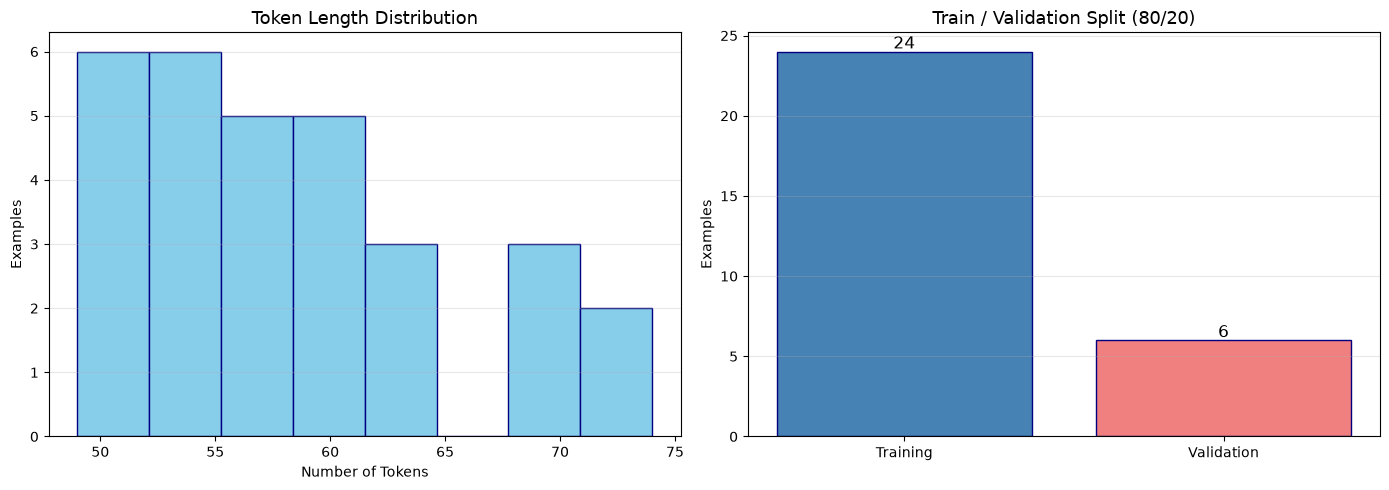

In [8]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(token_lengths, bins=8, color='skyblue', edgecolor='navy')
plt.title("Token Length Distribution", fontsize=13)
plt.xlabel("Number of Tokens")
plt.ylabel("Examples")
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(["Training", "Validation"], [len(train_data), len(val_data)],
        color=['steelblue', 'lightcoral'], edgecolor='navy')
plt.title("Train / Validation Split (80/20)", fontsize=13)
plt.ylabel("Examples")
plt.grid(axis='y', alpha=0.3)
for i, count in enumerate([len(train_data), len(val_data)]):
    plt.text(i, count + 0.2, str(count), ha='center', fontsize=12)

plt.tight_layout()
plt.savefig("day3_dataset_prep.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Takeaways
- Always check for duplicates and missing fields before training
- Chat templates convert raw JSON into model-ready text
- Loss masking sets -100 for system/user tokens so only assistant responses train the model
- Training in 80/20 split; validation catches overfitting
- Dataset quality matters more than dataset size